# 02. 전체 EDA 파이프라인 (근거 통합본)

팀 가이드의 8단계(①데이터이해 → ②기본전처리 → ③파생변수생성 → ④파생변수 이상치확인 → ⑤단변량EDA → ⑥이변량EDA → ⑦다변량EDA → ⑧통계검정)를 순서대로 채우고, **모든 의사결정의 근거(왜 500달러인지, 왜 이 파생변수를 만들었는지, 왜 지역분석은 뺐는지 등)를 이 문서 하나에 전부 포함**했습니다.

이 문서 하나만 보면 결과와 근거가 처음부터 끝까지 다 나옵니다.

## ① 데이터 이해

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("fraudTrain.csv")
print(df.shape)
df.head()

(1296675, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## ② 기본 전처리 (결측치, 자료형, 중복, 삭제)

In [39]:
print('결측치:', df.isnull().sum().sum())
print('중복행:', df.duplicated().sum())

결측치: 0
중복행: 0


In [40]:
# 자료형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# 나이 파생변수 -> 실제 거래 발생 연도 기준
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

df[['trans_date_trans_time','dob','age']].head()

,trans_date_trans_time,dob,age
0,2019-01-01 00:00:18,1988-03-09,31
1,2019-01-01 00:00:44,1978-06-21,41
2,2019-01-01 00:00:51,1962-01-19,57
3,2019-01-01 00:01:16,1967-01-12,52
4,2019-01-01 00:03:06,1986-03-28,33


In [41]:
# 기본 통계 (amt, age, city_pop) -> 이상값(음수, 너무 큰 값) 있는지 확인
df[['amt','age','city_pop']].describe()

,amt,age,city_pop
count,1.296675e+06,1.296675e+06,1.296675e+06
mean,7.035104e+01,4.602930e+01,8.882444e+04
std,1.603160e+02,1.738237e+01,3.019564e+05
min,1.000000e+00,1.400000e+01,2.300000e+01
25%,9.650000e+00,3.300000e+01,7.430000e+02
50%,4.752000e+01,4.400000e+01,2.456000e+03
75%,8.314000e+01,5.700000e+01,2.032800e+04
max,2.894890e+04,9.600000e+01,2.906700e+06


In [42]:
# 왜도(skew)/첨도(kurtosis) -> 분포가 한쪽으로 치우쳤는지, 극단치가 있는지 확인
for col in ['amt', 'age', 'city_pop']:
    print(f"{col}: 왜도(skew)={stats.skew(df[col]):.2f}, 첨도(kurtosis)={stats.kurtosis(df[col]):.2f}")

amt: 왜도(skew)=42.28, 첨도(kurtosis)=4545.63
age: 왜도(skew)=0.61, 첨도(kurtosis)=-0.18
city_pop: 왜도(skew)=5.59, 첨도(kurtosis)=37.61


In [43]:
# 삭제 -> 분석/모델링에 의미 없는 컬럼 실제로 제거
# Unnamed: 0 (그냥 행번호), trans_num(거래 고유ID), first/last(이름, 개인식별정보),
# street(주소 상세 - lat/long으로 이미 위치 정보 확보됨)
drop_cols = ['Unnamed: 0', 'trans_num', 'first', 'last', 'street']
df = df.drop(columns=drop_cols)
print('삭제 후 컬럼 수:', df.shape[1])
df.columns.tolist()

삭제 후 컬럼 수: 19


['trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'gender',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'age']

## ②-1. 왜 이 파생변수들을 만드는가 — EDA로 근거 확보

파생변수를 만들기 전에, **원본 데이터만으로 먼저 패턴을 찾아보고** 그 근거로 파생변수를 설계합니다. (금액 임계값 500불이 왜 나왔는지 등 모든 결정의 근거가 여기 있음)

In [44]:
# 전체 사기 비율 + 업종별 사기 비율 -> 가설3(업종별 동적 피처)의 근거
print('전체 사기 비율:', df['is_fraud'].mean())
print()
print(df.groupby('category')['is_fraud'].mean().sort_values(ascending=False))

전체 사기 비율: 0.005788651743883394

category
shopping_net      0.017561
misc_net          0.014458
grocery_pos       0.014098
shopping_pos      0.007225
gas_transport     0.004694
misc_pos          0.003139
grocery_net       0.002948
travel            0.002864
entertainment     0.002478
personal_care     0.002424
kids_pets         0.002114
food_dining       0.001651
home              0.001608
health_fitness    0.001549
Name: is_fraud, dtype: float64


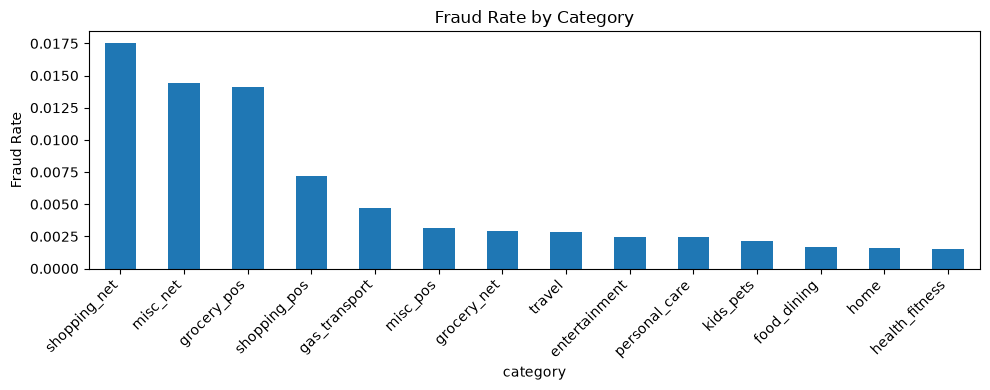

In [45]:
# 업종별 사기 비율을 그래프로 -> 온라인(net) 계열이 눈에 띄게 높다는 걸 시각적으로 확인
plt.figure(figsize=(10, 4))
df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Fraud Rate by Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
# 금액대별 사기 비율 -> 가설2의 '500불' 임계값이 나온 근거
# 100달러 이하까지는 1% 미만인데, 500달러를 넘는 순간 사기비율이 계단처럼 확 뛰는 지점을 찾음
print(df.groupby(pd.cut(df['amt'], bins=[0,10,50,100,500,1000,100000]), observed=True)['is_fraud'].mean())

amt
(0, 10]           0.001563
(10, 50]          0.003217
(50, 100]         0.000116
(100, 500]        0.010061
(500, 1000]       0.230782
(1000, 100000]    0.241108
Name: is_fraud, dtype: float64


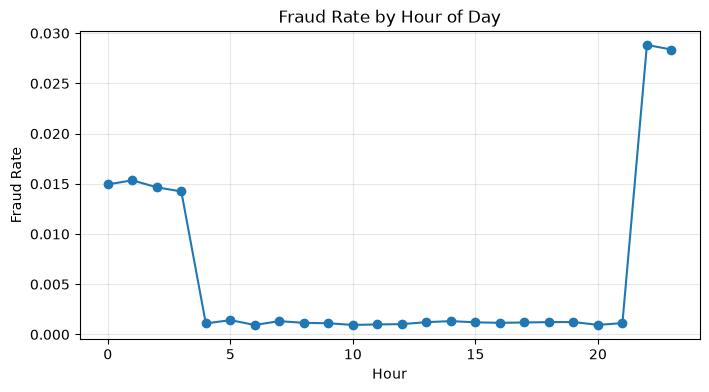

hour
0     0.014940
1     0.015349
2     0.014652
3     0.014239
4     0.001099
5     0.001423
6     0.000946
7     0.001327
8     0.001153
9     0.001114
10    0.000946
11    0.000998
12    0.001027
13    0.001225
14    0.001325
15    0.001208
16    0.001156
17    0.001192
18    0.001226
19    0.001236
20    0.000952
21    0.001129
22    0.028829
23    0.028374
Name: is_fraud, dtype: float64

In [47]:
# 시간대별 사기 비율 -> 심야 시간대 위험이 압도적으로 높다는 근거 (가장 강력한 패턴)
df['hour'] = df['trans_date_trans_time'].dt.hour
hourly_fraud = df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(8, 4))
hourly_fraud.plot(kind='line', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.grid(alpha=0.3)
plt.show()

hourly_fraud

In [48]:
# 실제 카드 사례로 '몰아쓰기(burst spending)' 패턴 육안 확인 -> 가설2가 왜 말이 되는지 보여주는 증거
example_card = df[df['cc_num'] == 4613314721966].sort_values('trans_date_trans_time')
print('이 카드의 평소(정상거래) 평균 금액:', round(example_card.loc[example_card['is_fraud']==0, 'amt'].mean(), 2))
example_card[['trans_date_trans_time','category','amt','is_fraud']].head(16)

이 카드의 평소(정상거래) 평균 금액: 96.8


,trans_date_trans_time,category,amt,is_fraud
1023,2019-01-01 12:51:40,home,71.03,0
2449,2019-01-02 01:06:37,grocery_pos,281.06,1
2546,2019-01-02 03:38:03,gas_transport,7.03,1
2937,2019-01-02 13:38:08,shopping_net,844.80,1
3527,2019-01-02 23:52:08,misc_net,843.91,1
4654,2019-01-03 22:21:15,shopping_net,942.62,1
4706,2019-01-03 23:09:51,shopping_pos,821.96,1
4727,2019-01-03 23:29:57,shopping_net,1092.68,1
4740,2019-01-03 23:41:36,shopping_net,1254.27,1
4950,2019-01-04 04:08:19,misc_pos,32.66,0


## ③ 파생변수 생성 (가설에 필요한 변수)

**가설2**: 단시간 내 고액(500불↑) 반복결제 -> burst spending 탐지
**가설3**: 업종별 최근 h기간 사기비율 -> Data Drift 적응형 피처

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# 온라인 결제 여부 플래그 -> category가 '_net'으로 끝나면 온라인 결제(grocery_net, misc_net, shopping_net)
# 온라인 결제는 실제로 '가맹점 위치'까지 이동한 게 아니므로, 거리/속도 파생변수에서 제외 대상
df['is_online'] = df['category'].str.endswith('_net')

# 가설2용: 카드별 시간 흐름 순으로 정렬 후 직전 거래와의 시간차, 24h 반복횟수
df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
# 주의: unix_time 컬럼이 trans_date_trans_time과 미세하게 안 맞는 행이 있어서(원본 데이터 특성),
#      unix_time으로 diff하면 드물게 음수 시간차가 나옴 -> 우리가 정렬 기준으로 쓴
#      trans_date_trans_time으로 직접 계산해서 이 불일치를 원천 차단
df['time_diff_sec'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds()
df['is_high_amt'] = (df['amt'] >= 500).astype(int)

df_time_idx = df.set_index('trans_date_trans_time')
df['recent_24h_txn_count'] = (
    df_time_idx.groupby('cc_num')['amt'].rolling('24h', closed='left', min_periods=0).count().values
)
df['recent_24h_high_amt_count'] = (
    df_time_idx.groupby('cc_num')['is_high_amt'].rolling('24h', closed='left', min_periods=0).sum().values
)

# 가설3용: 업종별 최근 7일 사기비율 (rolling)
df = df.sort_values(['category', 'trans_date_trans_time']).reset_index(drop=True)
df_time_idx = df.set_index('trans_date_trans_time')
df['category_recent_fraud_rate'] = (
    df_time_idx.groupby('category')['is_fraud'].rolling('7D', closed='left').mean().values
)
overall_fraud_rate = df['is_fraud'].mean()
df['category_recent_fraud_rate'] = df['category_recent_fraud_rate'].fillna(overall_fraud_rate)

# 거리: 고객 평소 위치 vs 가맹점 위치
# -> 온라인 결제는 '이동'이 성립하지 않으므로 distance_km_2을 NaN 처리 (오프라인 결제만 유효한 값을 가짐)
df['distance_km_2'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
df.loc[df['is_online'], 'distance_km_2'] = np.nan

df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
print('온라인 결제 비율:', df['is_online'].mean().round(4), '-> distance_km_2에서 제외된 행 수:', df['is_online'].sum())
df[['cc_num','trans_date_trans_time','category','is_online','amt','recent_24h_high_amt_count','category_recent_fraud_rate','distance_km_2']].head()

## ④ 파생변수 이상치 확인 (거리, 속도, 시간차)

"속도"는 아직 안 만들었으니 여기서 새로 만듭니다: **같은 카드가 연속으로 결제한 두 가맹점 사이의 거리 ÷ 그 사이 걸린 시간 = 이동속도**. 물리적으로 불가능한 속도(예: 시속 500km 이상)가 나오면 카드 도용(한 카드가 동시에 두 곳에서 쓰인 것) 의심 신호입니다.

In [ ]:
# 이동속도는 '물리적으로 실제 이동했다'는 게 전제라서, 온라인(_net) 결제가 끼면 의미가 깨짐
# (온라인 거래의 merch_lat/merch_long은 실제 이동 목적지가 아님)
# -> 오프라인(POS) 거래만 따로 뽑아서, '직전 오프라인 결제 가맹점' 기준으로 거리/속도 계산
df_offline = df[~df['is_online']].sort_values(['cc_num', 'trans_date_trans_time']).copy()

df_offline['prev_merch_lat'] = df_offline.groupby('cc_num')['merch_lat'].shift(1)
df_offline['prev_merch_long'] = df_offline.groupby('cc_num')['merch_long'].shift(1)
df_offline['prev_trans_time'] = df_offline.groupby('cc_num')['trans_date_trans_time'].shift(1)

df_offline['merchant_shift_km'] = haversine(
    df_offline['prev_merch_lat'], df_offline['prev_merch_long'],
    df_offline['merch_lat'], df_offline['merch_long']
)

# 시간차도 '직전 오프라인 결제'와의 차이로 다시 계산 (기존 time_diff_sec은 온라인 포함이라 안 씀)
df_offline['time_diff_hr'] = (
    (df_offline['trans_date_trans_time'] - df_offline['prev_trans_time']).dt.total_seconds() / 3600
)

# 속도(km/h) = 이동거리 / 걸린시간  (시간차가 0에 가까우면 속도가 무한대로 튀니 최소값 제한)
df_offline['speed_2'] = df_offline['merchant_shift_km'] / df_offline['time_diff_hr'].clip(lower=1/60)  # 최소 1분(1/60시간)으로 하한

# 오프라인 기준으로 계산한 결과를 원본 df에 반영 (온라인 행 + 오프라인 첫 거래는 NaN으로 남음)
df['merchant_shift_km'] = np.nan
df['time_diff_hr'] = np.nan
df['speed_2'] = np.nan
df.loc[df_offline.index, 'merchant_shift_km'] = df_offline['merchant_shift_km']
df.loc[df_offline.index, 'time_diff_hr'] = df_offline['time_diff_hr']
df.loc[df_offline.index, 'speed_2'] = df_offline['speed_2']

print('speed_2 계산 대상(오프라인) 행 수:', df_offline.shape[0], '/ 전체:', df.shape[0])
df[['is_online','merchant_shift_km','time_diff_hr','speed_2']].describe()

In [ ]:
# 거리 구간별 사기 비율 + is_fraud와의 상관계수 -> distance_km_2 자체가 위험신호로 쓸만한지 검증
print(df.groupby(pd.cut(df['distance_km_2'], bins=[0,20,40,60,80,100,150]), observed=True)['is_fraud'].mean())
print()
print('distance_km_2과 is_fraud 상관계수:', df['distance_km_2'].corr(df['is_fraud']))

In [ ]:
# 이상치 확인 -> 박스플롯으로 세 파생변수(거리, 속도, 시간차) 분포 한눈에
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(y=df['distance_km_2'], ax=axes[0])
axes[0].set_title('distance_km_2')

sns.boxplot(y=df['speed_2'].clip(upper=2000), ax=axes[1])  # 그래프 보기용으로 2000 초과는 자름
axes[1].set_title('speed_2 (clipped at 2000)')

sns.boxplot(y=df['time_diff_sec'].clip(upper=200000), ax=axes[2])
axes[2].set_title('time_diff_sec (clipped at 200000)')

plt.tight_layout()
plt.show()

print('물리적으로 말이 안 되는 속도(시속 500km 이상) 건수:', (df['speed_2'] > 500).sum())
print('그중 사기 비율:', df.loc[df['speed_2'] > 500, 'is_fraud'].mean())

## ⑤ 단변량 EDA

원본 변수와 우리가 만든 파생변수, 둘 다의 분포를 확인

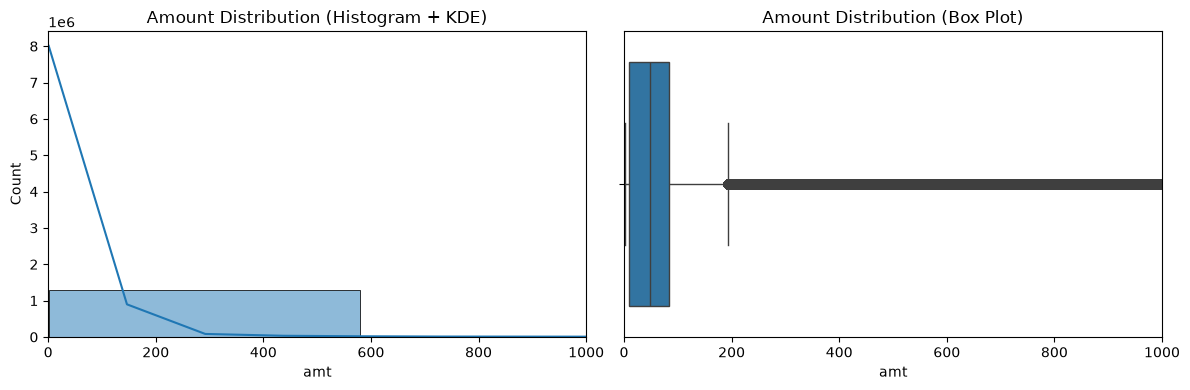

In [53]:
# 연속형(amt) 분포 -> Histogram + KDE / Box Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['amt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Amount Distribution (Histogram + KDE)')
axes[0].set_xlim(0, 1000)

sns.boxplot(x=df['amt'], ax=axes[1])
axes[1].set_title('Amount Distribution (Box Plot)')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

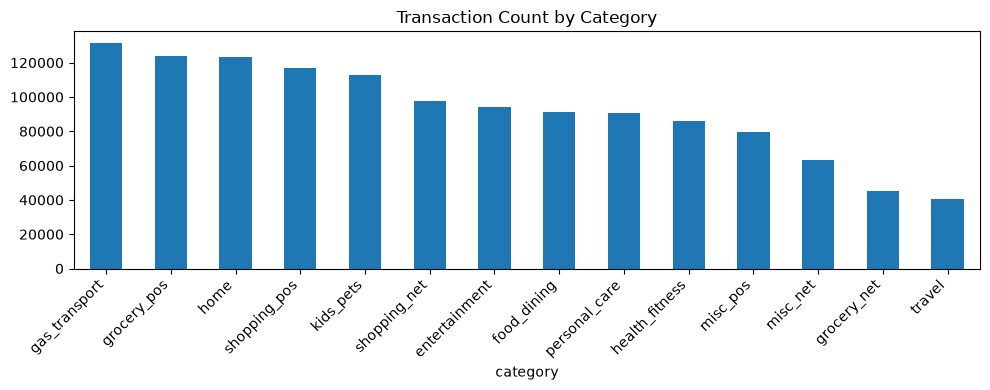

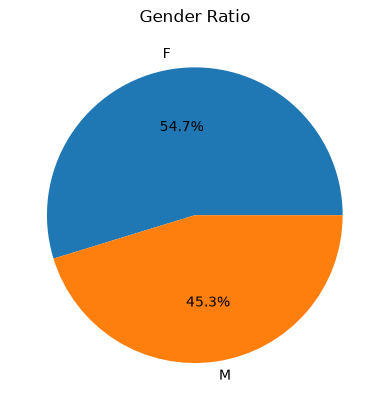

In [54]:
# 범주형(category, gender) 분포 -> Bar Chart / Pie Chart
fig, ax = plt.subplots(figsize=(10, 4))
df['category'].value_counts().plot(kind='bar', ax=ax)
plt.title('Transaction Count by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Ratio')
plt.ylabel('')
plt.show()

In [ ]:
# 우리가 만든 파생변수 자체의 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['recent_24h_high_amt_count'], bins=20, ax=axes[0])
axes[0].set_title('recent_24h_high_amt_count Distribution')

sns.histplot(df['category_recent_fraud_rate'], bins=30, ax=axes[1])
axes[1].set_title('category_recent_fraud_rate Distribution')

sns.histplot(df['distance_km_2'], bins=30, ax=axes[2])
axes[2].set_title('distance_km_2 Distribution')

plt.tight_layout()
plt.show()

## ⑥ 이변량 EDA (가설 검증용)

원본 변수와 파생변수 각각을 `is_fraud`와 직접 비교

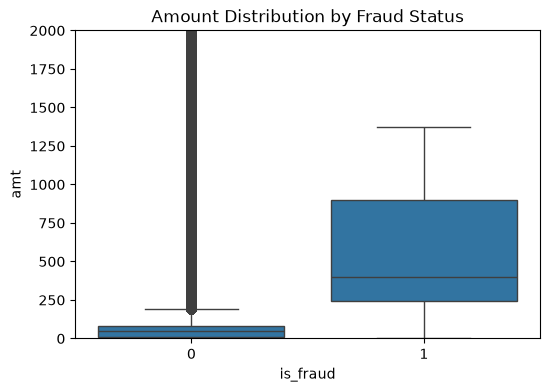

In [56]:
# X=범주(is_fraud), Y=연속(amt) -> 정상/사기 그룹 간 금액 분포 비교
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.ylim(0, 2000)
plt.title('Amount Distribution by Fraud Status')
plt.show()

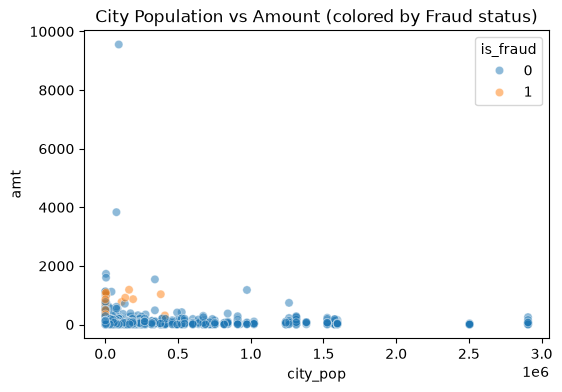

In [57]:
# X=연속(city_pop), Y=연속(amt) -> Scatter (전체 다 찍으면 느려서 5000개만 샘플링)
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(6, 4))
sns.scatterplot(x='city_pop', y='amt', hue='is_fraud', data=sample, alpha=0.5)
plt.title('City Population vs Amount (colored by Fraud status)')
plt.show()

In [ ]:
# 담당 가설용 파생변수들을 is_fraud와 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='is_fraud', y='recent_24h_high_amt_count', data=df, ax=axes[0])
axes[0].set_title('Hypothesis 2: high-amt burst count by Fraud')

sns.boxplot(x='is_fraud', y='category_recent_fraud_rate', data=df, ax=axes[1])
axes[1].set_title('Hypothesis 3: category recent fraud rate by Fraud')

sns.boxplot(x='is_fraud', y=df['speed_2'].clip(upper=1000), data=df, ax=axes[2])
axes[2].set_title('speed_2 by Fraud (clipped 1000)')

plt.tight_layout()
plt.show()

### 시간/지역 축으로도 가설 검증 — 요일, 월별 추이(드리프트), 지역

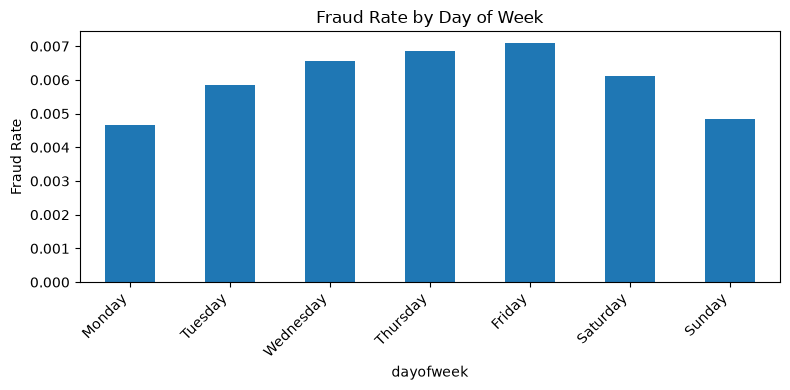

dayofweek
Monday       0.004648
Tuesday      0.005835
Wednesday    0.006554
Thursday     0.006844
Friday       0.007086
Saturday     0.006106
Sunday       0.004853
Name: is_fraud, dtype: float64

In [59]:
# 요일별 사기 비율 -> 시간대(hour) 패턴의 보조 신호
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['dayofweek'] = df['trans_date_trans_time'].dt.day_name()
dow_fraud = df.groupby('dayofweek')['is_fraud'].mean().reindex(day_order)

plt.figure(figsize=(8, 4))
dow_fraud.plot(kind='bar')
plt.title('Fraud Rate by Day of Week')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

dow_fraud

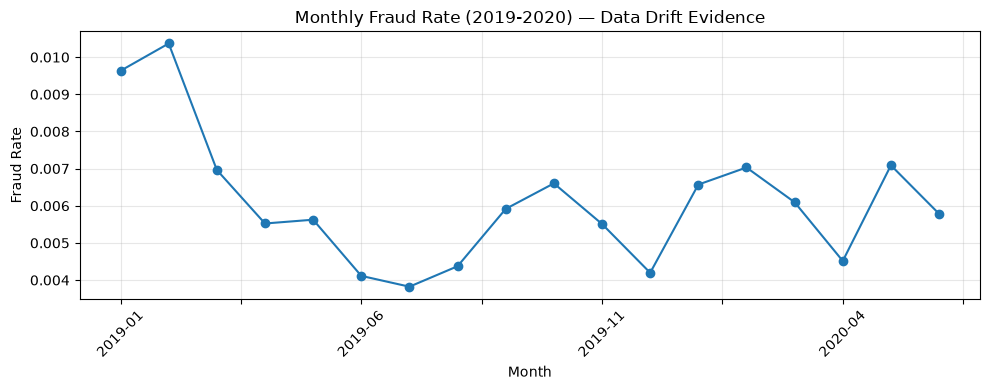

year_month
2019-01    0.009634
2019-02    0.010368
2019-03    0.006964
2019-04    0.005523
2019-05    0.005625
2019-06    0.004113
2019-07    0.003822
2019-08    0.004373
2019-09    0.005916
2019-10    0.006603
2019-11    0.005510
2019-12    0.004197
2020-01    0.006571
2020-02    0.007031
2020-03    0.006095
2020-04    0.004515
2020-05    0.007089
2020-06    0.005784
Name: is_fraud, dtype: float64

In [60]:
# 2년 전체 기간 월별 사기율 추이 -> 가설3(Data Drift)의 전제("시간 지나면 패턴이 바뀐다")를 실제로 검증
df['year_month'] = df['trans_date_trans_time'].dt.to_period('M').astype(str)
monthly_fraud = df.groupby('year_month')['is_fraud'].mean()

plt.figure(figsize=(10, 4))
monthly_fraud.plot(kind='line', marker='o')
plt.title('Monthly Fraud Rate (2019-2020) — Data Drift Evidence')
plt.xlabel('Month')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

monthly_fraud

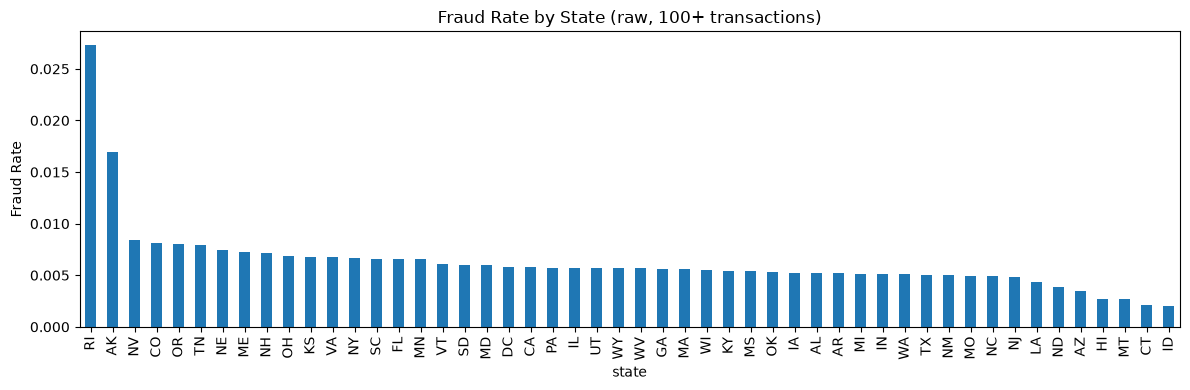

state
RI    0.027273
AK    0.016981
NV    0.008382
CO    0.008141
OR    0.008012
Name: is_fraud, dtype: float64

In [61]:
# 지역(state)별 사기 집중도 -> 시도해봤지만 아래에서 신뢰할 수 없다고 판단, 그 근거까지 같이 남김
state_counts = df['state'].value_counts()
valid_states = state_counts[state_counts >= 100].index
state_fraud = df[df['state'].isin(valid_states)].groupby('state')['is_fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
state_fraud.plot(kind='bar')
plt.title('Fraud Rate by State (raw, 100+ transactions)')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

state_fraud.head(5)

In [62]:
# 위 순위 상위 주(state)를 그대로 믿어도 되는지 검증 -> 카드(고객) 수를 확인
for state in state_fraud.head(3).index:
    sub = df[df['state'] == state]
    print(f"{state}: 거래 {len(sub)}건, 사기 {int(sub['is_fraud'].sum())}건, 카드 수 {sub['cc_num'].nunique()}개")

print()
print('==> 이 데이터셋은 카드 소지자가 전체 1,000명뿐이라, 주(state) 단위로 쪼개면')
print('    표본이 개인 몇 명 수준으로 줄어들어 "지역 위험도"가 아니라 "그 개인의 우연한 사기 이력"이')
print('    지역 패턴처럼 보이는 착시가 발생함. -> 지역별 분석은 이 데이터셋 특성상 신뢰 불가로 결론.')

RI: 거래 550건, 사기 15건, 카드 수 1개
AK: 거래 2120건, 사기 36건, 카드 수 3개
NV: 거래 5607건, 사기 47건, 카드 수 5개

==> 이 데이터셋은 카드 소지자가 전체 1,000명뿐이라, 주(state) 단위로 쪼개면
    표본이 개인 몇 명 수준으로 줄어들어 "지역 위험도"가 아니라 "그 개인의 우연한 사기 이력"이
    지역 패턴처럼 보이는 착시가 발생함. -> 지역별 분석은 이 데이터셋 특성상 신뢰 불가로 결론.


## ⑦ 다변량 EDA (상관분석, Heatmap, VIF)

In [ ]:
num_cols = ['amt', 'age', 'city_pop', 'distance_km_2', 'speed_2',
            'recent_24h_txn_count', 'recent_24h_high_amt_count',
            'category_recent_fraud_rate', 'is_fraud']

# distance_km_2/speed_2는 온라인 결제라서 NaN인 건데, fillna(0)으로 채우면
# '거리를 모름'이 '거리 0'으로 둔갑해 상관계수가 왜곡됨
# -> fillna(0) 없이 그대로 corr() 호출 (pandas가 쌍(pair)마다 NaN 있는 행만 알아서 제외함)
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# VIF (분산팽창계수) -> 피처들끼리 서로 겹치는 정보가 너무 많은지(다중공선성) 확인
# 보통 VIF > 10이면 다중공선성이 심하다고 판단
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['amt', 'age', 'city_pop', 'distance_km_2', 'speed_2',
            'recent_24h_txn_count', 'recent_24h_high_amt_count', 'category_recent_fraud_rate']

# VIF는 corr()와 달리 행렬 전체를 한 번에 계산해서 '쌍별 제외'가 안 됨 -> fillna(0) 대신
# NaN이 있는 행(온라인 결제, 카드별 첫 오프라인 거래)을 통째로 제외(dropna)해야 왜곡이 없음
X_vif = df[vif_cols].dropna()
print(f'VIF 계산에 사용된 행: {len(X_vif)} / 전체 {len(df)} (NaN {len(df) - len(X_vif)}건 제외)')

vif_result = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

vif_result

## ⑧ 통계검정 (t-test, 카이제곱)

지금까지는 "평균이 다르다", "상관계수가 높다"고만 말했는데, 이게 **우연이 아니라 통계적으로 유의미한 차이인지** 검정.

In [65]:
# t-test: 정상거래 vs 사기거래의 recent_24h_high_amt_count 평균이 정말 다른가?
normal_group = df.loc[df['is_fraud'] == 0, 'recent_24h_high_amt_count']
fraud_group = df.loc[df['is_fraud'] == 1, 'recent_24h_high_amt_count']

t_stat, p_value = stats.ttest_ind(normal_group, fraud_group, equal_var=False)
print(f'정상 평균: {normal_group.mean():.3f}, 사기 평균: {fraud_group.mean():.3f}')
print(f't-statistic: {t_stat:.2f}, p-value: {p_value:.2e}')
print('결론:', '통계적으로 유의미한 차이 있음 (p < 0.05)' if p_value < 0.05 else '유의미한 차이 없음')

정상 평균: 0.039, 사기 평균: 1.693
t-statistic: -91.02, p-value: 0.00e+00
결론: 통계적으로 유의미한 차이 있음 (p < 0.05)


In [66]:
# 카이제곱 검정: 업종(category)과 사기여부(is_fraud)가 서로 관련이 있는가? (둘 다 범주형이라 카이제곱 사용)
contingency = pd.crosstab(df['category'], df['is_fraud'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f'chi2 statistic: {chi2:.2f}, p-value: {p_value:.2e}, 자유도: {dof}')
print('결론:', '업종과 사기 여부는 서로 관련이 있음 (p < 0.05)' if p_value < 0.05 else '관련 없음')

chi2 statistic: 6486.00, p-value: 0.00e+00, 자유도: 13
결론: 업종과 사기 여부는 서로 관련이 있음 (p < 0.05)


## 보너스. 고위험군(사기 거래) 세분화 — K-means 클러스터링

지금까지 만든 `recent_24h_high_amt_count` 하나의 상관계수만으로는 "왜 위험한지" 세부 유형까지는 구분이 안 됨. 사기(`is_fraud=1`)로 판정된 거래만 모아서 유형별로 묶어봄.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# distance_km_2은 상관계수 0.0004로 클러스터 구분에 기여도가 거의 없었고(세 그룹 다 75~78km로 동일했음),
# 온라인 결제는 distance_km_2이 NaN이라 이 변수를 쓰면 사기의 37%(온라인)를 통째로 빼야 하는 문제가 있었음
# -> distance_km_2을 클러스터링 변수에서 제외하고, 온라인+오프라인 사기 전체(7,506건)를 다시 클러스터링
fraud_df = df[df['is_fraud'] == 1].copy()
print(f'클러스터링 대상 사기 거래: {len(fraud_df)}건 (온라인 {fraud_df["is_online"].sum()}건 포함, 이전에는 이 중 온라인이 빠져있었음)')

cluster_features = ['amt', 'recent_24h_high_amt_count']
X = fraud_df[cluster_features]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
fraud_df['risk_cluster'] = kmeans.fit_predict(X_scaled)

fraud_df.groupby('risk_cluster')[cluster_features].mean().round(1).assign(
    건수=fraud_df['risk_cluster'].value_counts()
)

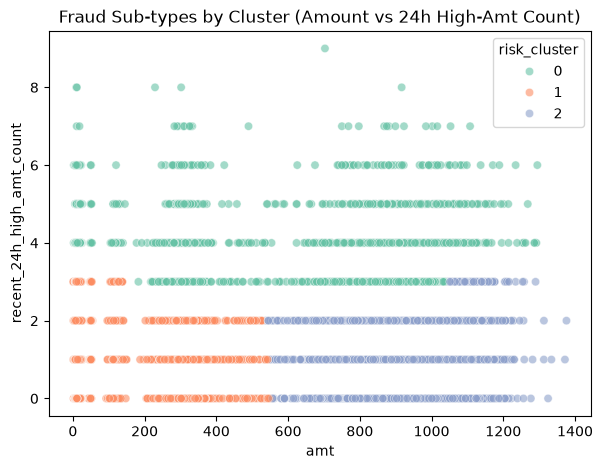

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='amt', y='recent_24h_high_amt_count', hue='risk_cluster', data=fraud_df, palette='Set2', alpha=0.6)
plt.title('Fraud Sub-types by Cluster (Amount vs 24h High-Amt Count)')
plt.show()

## 데이터 누수(Leakage) 체크리스트

- `recent_24h_txn_count`, `recent_24h_high_amt_count`, `category_recent_fraud_rate`는 전부 `closed='left'`를 사용해서, 이번 거래 자기 자신의 정답(`is_fraud`)이 자기 피처 계산에 섞이지 않도록 처리함
- 이 피처들은 train 데이터 자체의 과거 이력으로 계산한 것이라, **test 데이터에 적용할 때도 반드시 test 자신의 과거 이력만 사용**해야 함 (train 정보를 test 계산에 섞으면 안 됨)
- `trans_num`, `first`, `last`, `street`처럼 의미 없거나 개인식별에 해당하는 컬럼은 ②에서 이미 실제로 삭제함
- `category_recent_fraud_rate`의 콜드스타트(과거 이력 없는 첫 거래) 행은 전체 평균으로 `fillna` — 극소수 케이스에 한해 약간의 미래정보 혼입 가능성 있음(엄밀하게 하려면 0 또는 고정 prior로 대체)

## 최종 요약

- **②-1**: 업종별/금액대별 사기율 표에서 **500달러 임계값의 근거**를 찾았고, 실제 카드 사례로 "몰아쓰기" 패턴을 눈으로 확인
- **③**: 그 근거들을 바탕으로 가설2·가설3용 파생변수(24h 반복횟수, 업종별 동적 사기율, 거리) 생성
- **④**: 새로 만든 `speed_2`(이동속도)로 물리적으로 불가능한 이동 탐지, 거리 구간별 사기율도 확인
- **⑤**: amt/category/gender 원본 변수 + 파생변수 자체의 분포 확인
- **⑥**: amt·city_pop·파생변수 전부 `is_fraud`와 비교, 요일·월별 추이(Data Drift 검증)·지역(신뢰불가 판정과 근거)까지 포함
- **⑦**: Heatmap + VIF로 다변량 관계와 다중공선성 확인
- **⑧**: t-test, 카이제곱으로 차이가 통계적으로 유의미한지 검정
- **보너스**: K-means로 사기 거래를 3가지 유형(소액단발/연속몰아쓰기/한탕고액)으로 세분화 + 산점도 시각화

**다음 단계**: 1단계 지도학습 분류모델 — 재현율(Recall) 중심 + ROC/PR 곡선 평가

## 추가. 교차 히트맵 — speed_2 × recent_24h_high_amt_count

⑦번 상관계수 표에서 `speed_2`(0.02, 온라인 결제 제외 후 재계산)와 `recent_24h_high_amt_count`(0.46)는 **단독**으로 봤을 때 값이 각자 따로 나왔음. 근데 다른 팀원이 "속도 × 30분내 연속결제횟수"를 조합한 교차 히트맵에서 단독 상관계수로는 안 보이던 강력한 비선형 패턴(최대 100%까지 사기율 급등)을 찾아낸 것을 보고, 같은 방식을 우리 피처 조합에도 적용해봄.

- **가로축**: `recent_24h_high_amt_count`를 구간(0/1/2/3/4+)으로 나눔
- **세로축**: `speed_2`를 구간(0-10/10-30/30-60/60-100/100-300/300+)으로 나눔
- **칸 값**: 그 조합에 해당하는 거래들의 실제 `is_fraud` 평균(%) — 상관계수가 아니라 진짜 사기 비율

In [ ]:
# 구간 나누기
df['speed_group'] = pd.cut(
    df['speed_2'],
    bins=[-0.1, 10, 30, 60, 100, 300, 1_000_000],
    labels=['0-10', '10-30', '30-60', '60-100', '100-300', '300+']
)
df['amt_count_group'] = pd.cut(
    df['recent_24h_high_amt_count'],
    bins=[-0.1, 0, 1, 2, 3, 100],
    labels=['0', '1', '2', '3', '4+']
)

# 조합별 표본 수도 같이 확인 (표본 너무 적은 칸은 비율이 과대평가될 수 있음)
cross_count = df.pivot_table(
    index='speed_group', columns='amt_count_group', values='is_fraud',
    aggfunc='count', observed=True
)

# 조합별 사기 비율(%)
cross_fraud = df.pivot_table(
    index='speed_group', columns='amt_count_group', values='is_fraud',
    aggfunc='mean', observed=True
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_fraud, annot=True, fmt='.2f', cmap='Reds')
plt.title('Fraud Rate(%) by Speed & 24h High-Amt Count')
plt.xlabel('recent_24h_high_amt_count group')
plt.ylabel('speed_2 group')
plt.tight_layout()
plt.show()

print('각 칸의 표본 수(적은 칸은 비율이 과대평가됐을 수 있음):')
cross_count

## 가설 검증 (다영 담당)

**가설 수정**

- 가설2 (원본): 단시간 내 특정 금액대(500불↑) 결제 연속 횟수를 측정하면, 카드 정지 전 최대한 활용하려는(burst spending) 목적의 이상거래 탐지 정확도를 높일 수 있을 것이다.
  >> **단독 검증됨** — `recent_24h_high_amt_count` 상관계수 0.46(다른 모든 피처 중 최고), t-test p<0.05로 정상/사기 그룹 간 평균 차이가 통계적으로 유의미함을 확인. (온라인 결제 제외 수정에도 값 변화 없음 — 이 피처는 온라인/오프라인 구분 없이 계산되는 게 맞기 때문)

- 가설3 (원본): 가맹점의 고정된 업종 정보 대신, 업종별 최근 h기간 사기비율이라는 자가 적응형 동적 피처를 쓰면 Data Drift 이후에도 재학습 없이 Precision 저하를 완화할 수 있다.
  >> **전제는 검증, 단일 피처 효과는 약함** — 월별 사기율 추이에서 실제로 시간에 따라 패턴이 바뀌는 것(Data Drift)을 확인했으나, `category_recent_fraud_rate` 자체의 상관계수는 0.07로 약함. 카이제곱 검정에서 업종-사기 연관성은 유의미(p<0.05)했음. (단, 이 원본 가설의 핵심 주장인 "동적 피처가 재학습 없이 Precision 저하를 완화한다"는 부분은 실제 모델 비교 실험이 필요해 EDA 단계에서는 검증 불가 — 모델링 단계 과제로 남김)

- 추가 검증(거리/속도, 온라인 결제 제외 후 재검증): 처음엔 "집에서 먼 가맹점일수록, 이동속도가 빠를수록 위험할 것"이라 가정했으나, **거리(distance_km_2)는 상관계수 0.0004로 이상거래와 거의 무관, 속도(speed_2)도 단독으로는 0.02로 약함**(온라인 결제를 거리/속도 계산에서 제외하니 이전 수치(0.04)보다 더 낮아짐 — 이전 수치 일부는 온라인 거래를 "이동"으로 잘못 계산한 착시였을 가능성). 다만 **속도와 recent_24h_high_amt_count를 교차 히트맵으로 결합하니 특정 조합(고속+반복 3회 이상)에서 사기율이 최대 86.67%까지 치솟는 강력한 상호작용은 온라인 제외 후에도(표본 120건 기준) 그대로 유지됨**.

**결론**

- `recent_24h_high_amt_count`(24h 내 고액 반복결제)는 이상거래 탐지에서 가장 강력한 단일 특징으로 확인되었다.
- 이동거리(`distance_km_2`)는 이상거래와 관련성이 거의 없는 것으로 확인되었다.
- 이동속도(`speed_2`)는 단독으로는 약하며(온라인 결제 제외 후 재검증 결과 이전보다 더 약함), 반복결제 횟수와 결합했을 때만 이상거래와 매우 강한 관련성을 보인다.
- Data Drift(시간에 따른 사기 패턴 변화)는 실제로 존재함을 확인했으며, 이는 고정값이 아닌 동적 피처 설계가 필요하다는 가설3의 전제를 뒷받침한다. (다만 동적 피처가 실제로 Precision 저하를 완화하는지는 모델링 단계에서 별도 검증 필요)
- `recent_24h_high_amt_count` × `speed_2` 조합 피처와, K-means로 도출한 `risk_cluster`는 이상거래 탐지 모델에서 유용한 특징 변수(Feature)로 활용될 가능성이 높다.